# Test para armonización 

## 🚀 1. Set up e importaciones

Quería hacer una estructura más pro tipo proyecto, pero me daba problemas al cargar los .py de src en el notebook. Los meto en celdas y los oculto. Igualmente meto esto por si lo cambiamos más adelante.

In [3]:
import spacy
import sys, os
import pandas as pd
import re
from pathlib import Path
import langcodes # ⬅️

In [4]:
# --- CONFIGURACIÓN GLOBAL ---

# Asegurar que el notebook ve el proyecto raíz
sys.path.append(os.path.abspath(".."))

# Ajustes visuales
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 10)
pd.set_option("display.precision", 2)

print("Entorno preparado ✅")


Entorno preparado ✅


## 2. Data Sets



### 2.1. Selección de DataSets

En la fase inicial del proyecto definimos un conjunto común de variables necesarias para construir un clasificador de género musical basado en texto:

- `artist_name`
- `track_name`
- `lyrics`
- `genre`
- `release_date`

Comenzamos la armonización entre dos fuentes: **Genius Lyrics**, que aporta las letras completas sin procesar (“raw”), y **TCC Music**, que inicialmente parecía compatible. Tras unificar columnas y tipos, detectamos un problema fundamental: **las letras del dataset TCC estaban  preprocesadas** (tokenización, eliminación de signos de puntuación, lematización, pérdida de saltos de línea y estructura interna).

Este tipo de preprocesamiento es incompatible con tareas modernas de PLN, especialmente las basadas en **modelos Transformer**, que dependen de señales lingüísticas como la puntuación, la capitalización, la estructura de frase o las repeticiones características del estilo musical. Mezclar TCC con Genius generaría un corpus heterogéneo y sesgado, afectando negativamente a la calidad de los embeddings y al rendimiento del clasificador.

Por este motivo descartamos el dataset TCC y buscamos una alternativa con letras completas. Finalmente incorporamos el dataset **Multilingual Lyrics for Genre Classification** (Kaggle), que sí conserva las letras en formato natural y aporta etiquetas de género útiles para un enfoque supervisado.

Ambos datasets se armonizaron en un esquema común reducido:

- `title`
- `artist`
- `genre`
- `lyrics`

Este formato final nos permite entrenar un clasificador de género musical coherente y robusto, aplicable tanto con enfoques clásicos (TF-IDF) como con representaciones modernas basadas en **embeddings y Transformers**.


### 2.1 Definición del Mapa de Géneros Compartido

Centralizamos la lógica de unificación de categorías en un único diccionario para garantizar la coherencia. (Se explica más abajo)

## 2.2. Configuraciones Específicas

In [35]:
GENIUS_PATH = "../data/song_lyrics.csv"
MULTI_PATH = "../data/train.csv"

GENIUS_USECOLS = ["artist", "title", "lyrics", "tag", "language"]
MULTI_USECOLS = ["Artist" , "Song", "Genre", "Language", "Lyrics"]


In [36]:
GENRE_MAP = {
    "rap": "rap",
    "hip-hop": "rap",
    "hip hop": "rap",
    "hiphop": "rap",

    "rock": "rock",
    "pop": "pop",

    # OTHER
    "rb": "other",
    "r&b": "other",
    "metal": "other",
    "indie": "other",
    "folk": "other",
    "jazz": "other",
    "electronic": "other",
    "edm": "other",
    "country": "other",
    "misc": "other",
    "soul": "other",
    "blues": "other",
    "classical": "other",
}


In [37]:
GENIUS_CONFIG = {
    "path": GENIUS_PATH,
    "usecols": GENIUS_USECOLS,

    # renombrar 'tag' -> 'genre'
    "rename_map": {
        "tag": "genre"
    },

    # Genius ya está filtrado a inglés por defecto → no aplicamos filtro
    "filters": {
        "language_col": "language",
        "target_language": "en"
    },

    # limpieza especializada
    "lyrics_cleaner": "genius",

    # el mapa global de armonización
    "genre_map": GENRE_MAP,

    # etiqueta de origen
    "source": "genius"
}


In [38]:
MULTI_CONFIG = {
    "path": MULTI_PATH,
    "usecols": MULTI_USECOLS,

    # renombrar columnas al esquema común
    "rename_map": {
        "Artist": "artist",
        "Song": "title",
        "Genre": "genre",
        "Language": "language",
        "Lyrics": "lyrics"
    },

    # filtrar a idioma inglés
    "filters": {
        "language_col": "language",
        "target_language": "en"
    },

    # limpieza diferente (no tiene chorus/verse)
    "lyrics_cleaner": "multilingual",

    # mismo mapa de géneros
    "genre_map": GENRE_MAP,

    "source": "multilingual"
}


## 📥 3. Clase DataLoader

Clase de carga que permite cargar csv según las cols seleccionadas en los CONFIGS.
Clase encargada de la lectura eficiente de datos, incluyendo la lógica de chunking para manejar grandes archivos sin agotar la memoria.

In [11]:

class DataLoader:
    """
    Clase responsable de cargar un DataFrame desde un archivo CSV,
    manejar la selección de columnas y el muestreo por chunking.
    """
    def __init__(self, config, chunksize=None, sample_blocks=None):
        self.config = config
        self.chunksize = chunksize
        self.sample_blocks = sample_blocks
        self.dataset_name = self.config.get("source", "dataset").upper()
        self.path = Path(self.config["path"])
        self.usecols = self.config["usecols"]


    def _load_full(self):
        """Carga el dataset completo sin muestreo."""
        print("\n Cargando dataset completo (sin muestreo)...")
        df = pd.read_csv(self.path, usecols=self.usecols)
        print(f" Dataset completo cargado con {len(df)} filas")
        return df

    def _load_sampled(self):
        """Carga el dataset usando muestreo (chunking)."""
        print(f"🔎 Muestreo → chunksize={self.chunksize:,}, sample_blocks={self.sample_blocks or 'todos'} bloques")

        chunks = pd.read_csv(self.path, usecols=self.usecols, chunksize=self.chunksize)
        parts = []
        for i, chunk in enumerate(chunks):
            print(f" Leyendo bloque {i+1}")
            parts.append(chunk)
            if self.sample_blocks and i + 1 >= self.sample_blocks:
                break

        df = pd.concat(parts, ignore_index=True)
        print(f" Muestra creada con {len(df)} filas")
        return df


    def load(self):
        """Orquesta la carga de datos (completa o muestreada) y devuelve el DataFrame."""
        print(f"\n Cargando dataset: {self.dataset_name}")

        if self.chunksize:
            return self._load_sampled()
        else:
            return self._load_full()

    def unique_values(self, column, chunksize=200_000):
        """
        Obtiene los valores únicos de una columna leyendo el CSV por chunks,
        sin cargar todo el dataset en memoria.
        """
        values = set()
        print(f"\n Obteniendo valores únicos de '{column}' en {self.dataset_name}...")
        for chunk in pd.read_csv(self.path, usecols=[column], chunksize=chunksize):
            vals = (
                chunk[column]
                .astype(str)
                .str.lower()
                .str.strip()
                .unique()
            )
            values.update(vals)

        return values

### 3.1 Carga muestreada de datasets con columnas relevantes


In [14]:
genius_loader = DataLoader(
    {"path": GENIUS_PATH, "usecols": GENIUS_USECOLS, "source": "genius"},
    chunksize=20000,
    sample_blocks=4
)
df_genius_raw = genius_loader.load()


multi_loader = DataLoader(
    {"path": MULTI_PATH, "usecols": MULTI_USECOLS, "source": "multilingual"},
       chunksize=20000,
    sample_blocks=4
)

df_multi_raw = multi_loader.load()



 Cargando dataset: GENIUS
🔎 Muestreo → chunksize=20,000, sample_blocks=4 bloques
 Leyendo bloque 1
 Leyendo bloque 2
 Leyendo bloque 3
 Leyendo bloque 4
 Muestra creada con 80000 filas

 Cargando dataset: MULTILINGUAL
🔎 Muestreo → chunksize=20,000, sample_blocks=4 bloques
 Leyendo bloque 1
 Leyendo bloque 2
 Leyendo bloque 3
 Leyendo bloque 4
 Muestra creada con 80000 filas


### 3.2 Carga completa de etiquetas

In [18]:
genius_genres = genius_loader.unique_values("tag")
multi_genres  = multi_loader.unique_values("Genre")

print("Genius:", genius_genres)
print("Multi:", multi_genres)


 Obteniendo valores únicos de 'tag' en GENIUS...

 Obteniendo valores únicos de 'Genre' en MULTILINGUAL...
Genius: {'rb', 'misc', 'country', 'rap', 'rock', 'pop'}
Multi: {'metal', 'country', 'folk', 'hip-hop', 'indie', 'jazz', 'rock', 'electronic', 'r&b', 'pop'}


## 4. Exploración y análisis armonización.

Realizamos una exploración de cada columna relevante de ambos data sets para identificar diferencias entre fuentes y aplicar las transformaciones que sean apropiadas.

### 4.1 Comparación de esquema entre datasets

In [31]:
df_genius_raw.head()

,title,tag,artist,lyrics,language
0,Killa Cam,rap,Cam'ron,"[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Killa Cam, Cam\nKilla Cam, Killa Cam\nKilla Cam, Cam\nKilla Cam, Killa Cam, Cam\nKilla Killa Killa Cam\nKilla Cam, Cam, Killa (Killa!)\nKilla Cam, Killa...",en
1,Can I Live,rap,JAY-Z,"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah, yeah, Roc-A-Fella\nWe invite you to somethin' epic, you know?\nWell, we hustle out of a sense of hopelessness\nSort of a desperation\nThrough that de...",en
2,Forgive Me Father,rap,Fabolous,Maybe cause I'm eatin\nAnd these bastards fiend for they grub\nI carry pumps like I serve gasoline to these scrubs\nHave you seen my Aston leanin on dubs\nAnd they can't afford chrome so they putt...,en
3,Down and Out,rap,Cam'ron,"[Produced by Kanye West and Brian Miller]\n\n[Intro: Cam'ron & Kanye West]\nUgh, Killa!\nBaby!\nKanye, this that 1970s Heron flow, huh?\nYeah, let's speed it up\nUgh, I'm back in, ugh, ugh\nThey d...",en
4,Fly In,rap,Lil Wayne,"[Intro]\nSo they ask me\n""Young boy\nWhat you gon' do the second time around?\nHow you gon' come back?""\nI tried told 'em\n""I come back like 32\nI jump back like 33""\nUgh, hit me\nThat's nothing\n...",en


In [32]:
df_multi_raw.head()

,Artist,Song,Genre,Language,Lyrics
0,12 stones,world so cold,Rock,en,"It starts with pain, followed by hate\nFueled by the endless questions no one can answer\nA stain covers your heart and tears you apart\nJust like a sleeping cancer\nI don't believe men are born t..."
1,12 stones,broken,Rock,en,Freedom!\nAlone again again alone\nPatiently waiting by the phone\nHoping that you will call me home\nThe pain inside my love denied\nHopes and dreams swallowed by pride\nEverything I need it lies...
2,12 stones,3 leaf loser,Rock,en,"Biting the hand that feeds you, lying to the voice\nInside, reach out to beg for something this life\nIs a lesson, take what you're given feeding on\nSelf destruction, waiting to explode again, no..."
3,12 stones,anthem for the underdog,Rock,en,You say you know just who I am\nBut you can't imagine\nWhat waits for you across the line\nYou thought you had me\nBut I'm still here standing\nAnd I'm tired of backing down\nAnd I'm here now feel...
4,12 stones,adrenaline,Rock,en,"My heart is beating faster can't control these feelings\nanymore,\nI've waited long enough I want it more than\nanyone,\nIts time to step up and deliver what you want to see,\nMy blood is pumping ..."


Observamos que hay que unificar el nombre de las columnas en primera instancia: pasar a minúscula los títulos del segundo dataset y aplicar (song->title).

### 4.2 Análisis de la columna genre

Dado que el objetivo principal es determinar los géneros, debemos elegir bien cómo vamos a unificar las clases de ambos data sets para que sea variado y consistente.

In [19]:
shared = genius_genres & multi_genres
only_genius = genius_genres - multi_genres
only_multi = multi_genres - genius_genres

print("🎧 Compartidos:", shared)
print("\n🟦 Solo en Genius:", only_genius)
print("\n🟪 Solo en Multilingual:", only_multi)


🎧 Compartidos: {'rock', 'country', 'pop'}

🟦 Solo en Genius: {'rb', 'misc', 'rap'}

🟪 Solo en Multilingual: {'metal', 'r&b', 'hip-hop', 'indie', 'jazz', 'folk', 'electronic'}


In [25]:
def top_genres(path, genre_col, n=30):
    df = pd.read_csv(path, usecols=[genre_col])
    return (
        df[genre_col]
        .astype(str)
        .str.lower()
        .str.strip()
        .value_counts()
        .head(n)
    )

print("Genius:")
print(top_genres(GENIUS_PATH, "tag"))

print("\nMultilingual:")
print(top_genres(MULTI_PATH, "Genre"))


Genius:
tag
pop        2138587
rap        1724816
rock        793220
rb          196462
misc        181455
country     100316
Name: count, dtype: int64

Multilingual:
Genre
rock          121404
pop           108714
metal          20291
jazz           13545
folk            8644
indie           8449
r&b             2793
hip-hop         2240
electronic      2213
country         1890
Name: count, dtype: int64


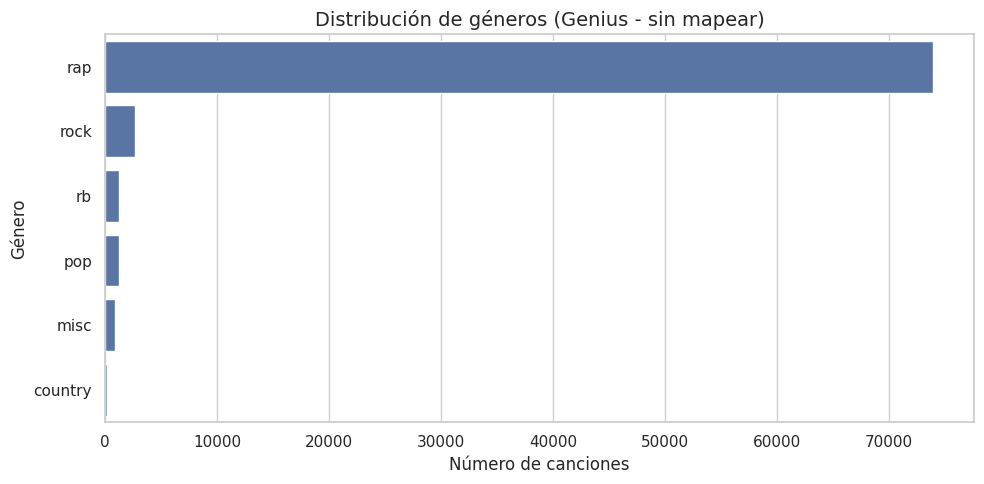

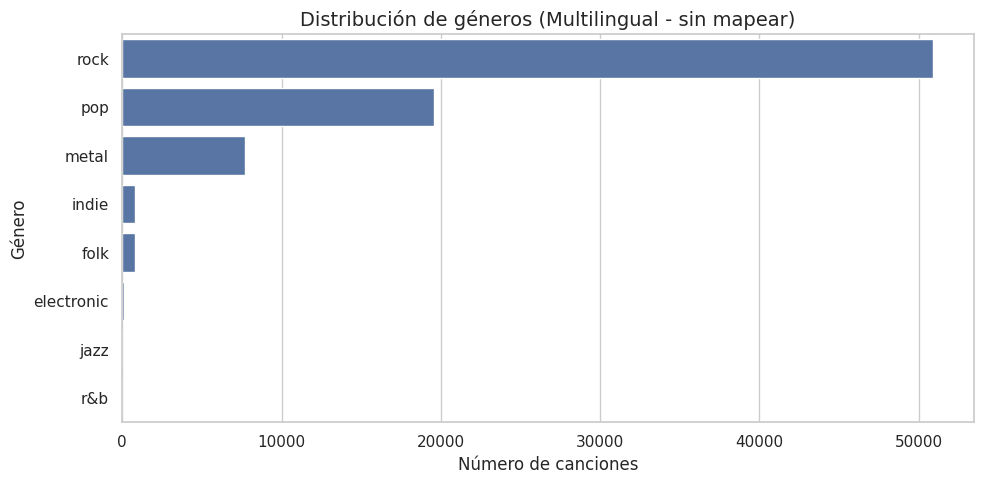

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_genre_distribution(series, title, top_n=20):
    """
    series: columna de géneros (pd.Series)
    title: título de la figura
    """
    counts = (
        series.astype(str)
        .str.lower()
        .str.strip()
        .value_counts()
        .head(top_n)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(title, fontsize=14)
    plt.xlabel("Número de canciones")
    plt.ylabel("Género")
    plt.tight_layout()
    plt.show()

plot_genre_distribution(
    df_genius_raw["tag"],
    "Distribución de géneros (Genius - sin mapear)"
)

plot_genre_distribution(
    df_multi_raw["Genre"],
    "Distribución de géneros (Multilingual - sin mapear)"
)


El objetivo era definir un conjunto de clases que fuera representativo, equilibrado y compatible con los patrones lingüísticos propios de los géneros musicales presentes en el corpus. Tras el análisis exploratorio de la distribución de etiquetas en los datasets Genius y Multilingual Lyrics, identificamos que los géneros con mayor soporte conjunto son **rap**, **rock** y **pop**, todos ellos presentes de forma abundante en ambas fuentes y con características estilísticas bien diferenciadas.

En cambio, etiquetas como *metal*, *jazz*, *indie*, *folk*, *electronic*, *country*, *r&b* o *misc* presentan una frecuencia significativamente menor o una elevada dispersión semántica, lo que dificulta su aprendizaje en modelos supervisados, en especial en escenarios con fuerte desbalance de clases. Para evitar estos problemas y asegurar un comportamiento estable, optamos por agrupar todas estas clases minoritarias o heterogéneas bajo una única etiqueta denominada **other**.

La decisión final, por tanto, consiste en trabajar con cuatro clases claramente definidas:
- **rap**, que agrupa rap y hip-hop;
- **rock**, presente en ambos datasets;
- **pop**, el género dominante en volumen;
- **other**, que actúa como categoría residual para los géneros de baja frecuencia o difícil caracterización.

Este diseño permite entrenar un clasificador multiclase robusto, interpretativo y con un nivel razonable de equilibrio entre categorías.


### 4.1 Mapeo final

In [29]:
GENRE_MAP = {
    # ---------------------------
    # CLASES PRINCIPALES
    # ---------------------------
    "rap": "rap",
    "hip-hop": "rap",
    "rock": "rock",
    "pop": "pop",

    # ---------------------------
    # OTHER
    # ---------------------------
    "rb": "other",
    "r&b": "other",
    "metal": "other",
    "indie": "other",
    "folk": "other",
    "jazz": "other",
    "electronic": "other",
    "edm": "other",
    "country": "other",
    "misc": "other",
    "soul": "other",
    "blues": "other",
    "classical": "other",
}

In [ ]:
VALID_GENRES = ["rap", "rock", "pop", "other"]

### 4.3 Análisis de la columna lyrics

La inspección inicial de las letras revela diferencias significativas entre los dos datasets.
En **Genius**, las letras incluyen numerosas anotaciones estructurales como:

- `[Chorus]`
- `[Intro]`
- `[Verse 1]`
- `[Bridge]`
- `[Produced by …]`

Además presentan múltiples saltos de línea (`\n`), caracteres adicionales y un formato más ruidoso pero también más expresivo.

En cambio, las letras del dataset **Multilingual Lyrics** aparecen en un formato mucho más limpio: sin etiquetas estructurales, con menos caracteres especiales y generalmente con una estructura más uniforme.

Esta asimetría entre fuentes hace necesaria una armonización para evitar sesgos durante el entrenamiento. No obstante, el texto de las letras es una señal lingüística fundamental para la clasificación de género, y un nivel de limpieza excesivo podría eliminar patrones característicos (repeticiones, jerga, rimas internas, densidad léxica), especialmente relevantes en géneros como rap o pop. Por este motivo, adoptamos una estrategia de limpieza **ligera y conservadora**. También dejamos los saltos de línea, ya que pueden dar información útil en el caso de las canciones.

Las transformaciones finales son:

- Eliminación de anotaciones artificiales (`[Chorus]`, `[Intro]`, `[Verse]`, `[Produced by...]`) de Genius.
- Normalización del texto a minúsculas.
- Unificación del formato de saltos de línea (`\n`) manteniendo su estructura.
- Normalización de espacios en blanco.
- Eliminación de caracteres no alfanuméricos innecesarios, preservando apóstrofes (cruciales para contracciones en inglés).
- No aplicar stemming ni lematización para mantener la riqueza léxica original.

Este enfoque permite conservar la estructura y ritmo propios de cada género, a la vez que elimina ruido no lingüístico, produciendo un corpus equilibrado entre expresividad y limpieza para su uso en modelos de PLN.


### 4.4. Exploración y análisis de la columna *artist*

La variable *artist* presenta diferencias de formato entre ambos datasets. En Genius incluye mayúsculas, apóstrofes y a veces múltiples artistas unidos por conectores como “&” o “feat.”. En Multilingual Lyrics aparecen nombres más normalizados, aunque también con variaciones en el uso de mayúsculas.
Las decisiones de limpieza son mínimas:

- Conversión a minúsculas.
- Eliminación de espacios sobrantes.
- Preservación de apóstrofes y caracteres válidos en nombres propios.
- No se desdoblan colaboraciones (“Lil Wayne & Drake”), ya que aportarían más ruido que información.


### 4.5. Exploración y análisis de la columna *title*

La variable *title* contiene el nombre de la canción y presenta ligeras diferencias entre datasets (p. ej., uso variable de mayúsculas, símbolos o numeración). Al no ser una característica clave para determinar el género musical, solo se aplica una normalización mínima:

- Conversión a minúsculas.
- Eliminación de espacios redundantes.
- Conservación del resto de símbolos y palabras, ya que forman parte del título real.

El título se conserva como metadato y no participa en el vector de entrada del modelo, aunque puede ser útil para inspeccionar la calidad del dataset y realizar análisis exploratorios.


### 4.6. Exploración y análisis de la columna *language*

El dataset Multilingual Lyrics incluye una columna *Language*, mientras que en Genius ya hemos aplicado un filtrado previo para quedarnos únicamente con canciones en inglés. El objetivo es construir un clasificador monolingüe que no mezcle características lingüísticas entre idiomas, por lo que es necesario aplicar el mismo criterio a ambos.

Las decisiones de armonización son:

- Filtrar el dataset Multilingual para conservar únicamente las entradas marcadas como inglés (`Language == "en"`).
- Eliminar la columna de idioma después del filtrado, ya que deja de ser necesaria.

Con este paso garantizamos que todos los ejemplos del corpus final pertenecen al mismo idioma, evitando que el modelo aprenda diferencias de género basadas accidentalmente en diferencias lingüísticas.


### 4.7. Conclusión del análisis previo a la armonización

El análisis detallado de las columnas de ambos datasets mostró inconsistencias en nombres, formatos, estructura del texto, distribución de géneros e información auxiliar. A partir de este estudio definimos un conjunto claro de transformaciones ligeras y coherentes que unifican ambas fuentes sin perder la información lingüística necesaria para la tarea de clasificación.

Estas decisiones guían la implementación del pipeline de armonización, formalizado en la clase `DatasetHarmonizer`, que aplica de forma sistemática todas las transformaciones establecidas.


## 4.2 DatasetHarmonizer

### 4.2.1. Funcionex auxiliares
Debido a que los dos datasets presentan diferencias importantes en el formato de las letras (por ejemplo, anotaciones estructurales en Genius o formato más limpio en Multilingual Lyrics), definimos dos funciones de limpieza específicas. Ambas siguen una estrategia ligera, preservando la estructura y semántica del texto, pero eliminando ruido no lingüístico.

- **`clean_genius_lyrics`** elimina etiquetas del tipo `[Chorus]`, `[Verse]`, `[Intro]`, normaliza saltos de línea y elimina caracteres extraños, manteniendo apóstrofes y la estructura del texto.
- **`clean_multilingual_lyrics`** aplica una limpieza mínima, ya que este dataset carece de anotaciones artificiales; simplemente normaliza minúsculas, saltos de línea y espacios.

Estas funciones garantizan que las letras de ambos datasets sean comparables y que la información estilística relevante se preserve para el entrenamiento del modelo.


In [40]:
import re

def clean_genius_lyrics(text):
    """
    Limpieza ligera para letras de Genius:
    - elimina etiquetas estructurales [Chorus], [Intro], etc.
    - mantiene saltos de línea (estructura original)
    - normaliza minúsculas
    - elimina caracteres raros pero conserva apóstrofes
    """
    if not isinstance(text, str):
        return ""

    # minúsculas
    text = text.lower()

    # eliminar etiquetas [Chorus], [Intro], etc.
    text = re.sub(r"\[.*?\]", " ", text)

    # normalizar saltos de línea a '\n'
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # eliminar caracteres no alfanuméricos (excepto apostrofes y saltos)
    text = re.sub(r"[^a-z0-9\n\s']", " ", text)

    # evitar espacios múltiples
    text = re.sub(r"[ ]{2,}", " ", text)

    # evitar saltos de línea excesivos
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def clean_multilingual_lyrics(text):
    """
    Limpieza mínima para Multilingual:
    - mantiene saltos de línea
    - normaliza espacios
    - minúsculas
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ ]{2,}", " ", text)

    return text.strip()


In [49]:
class DatasetHarmonizer:
    def __init__(self, df, config):
        self.df = df.copy()
        self.config = config
        self.dataset_name = config.get("source", "dataset").upper()

    # -----------------------------------------------------
    # 1. Renombrar columnas
    # -----------------------------------------------------
    def _rename_columns(self):
        rename_map = self.config.get("rename_map", {})
        if rename_map:
            self.df.rename(columns=rename_map, inplace=True)
        print(f"[{self.dataset_name}] ✓ Renombrado de columnas")

    # -----------------------------------------------------
    # 2. Normalizar tipos (genre, year)
    # -----------------------------------------------------
    def _normalize_types(self):
        if "genre" in self.df.columns:
            self.df["genre"] = (
                self.df["genre"]
                .astype(str)
                .str.lower()
                .str.strip()
            )
        if "year" in self.df.columns: # no se usa en nuestro caso al final
            self.df["year"] = pd.to_datetime(self.df["year"], errors="coerce").dt.year

        print(f"[{self.dataset_name}] ✓ Normalización de tipos")

    # -----------------------------------------------------
    # 3. Filtrar por idioma
    # -----------------------------------------------------
    def _filter_language(self):
        filters = self.config.get("filters", {})
        lang_col = filters.get("language_col")
        target_lang = filters.get("target_language")

        if lang_col and lang_col in self.df.columns:
            before = len(self.df)
            self.df = self.df[self.df[lang_col] == target_lang].copy()
            self.df.drop(columns=[lang_col], inplace=True)
            after = len(self.df)
            print(f"[{self.dataset_name}] ✓ Filtrado de idioma: {before} → {after}")

    # -----------------------------------------------------
    # 4. Limpieza de artist & title
    # -----------------------------------------------------
    def _clean_text_columns(self):

        # --- artist ---
        if "artist" in self.df.columns:
            self.df["artist"] = (
                self.df["artist"]
                .astype(str)
                .str.lower()
                .str.strip()
            )

        # --- title ---
        if "title" in self.df.columns:
            self.df["title"] = (
                self.df["title"]
                .astype(str)
                .str.lower()
                .str.strip()
            )

        print(f"[{self.dataset_name}] ✓ Limpieza de artist/title")

    # -----------------------------------------------------
    # 5. Limpieza ligera de lyrics
    # -----------------------------------------------------
    def _clean_lyrics(self):
        cleaner = self.config.get("lyrics_cleaner")

        if cleaner == "genius":
            self.df["lyrics"] = self.df["lyrics"].apply(clean_genius_lyrics)
        elif cleaner == "multilingual":
            self.df["lyrics"] = self.df["lyrics"].apply(clean_multilingual_lyrics)

        print(f"[{self.dataset_name}] ✓ Limpieza de lyrics")

    # -----------------------------------------------------
    # 6. Mapeo de géneros
    # -----------------------------------------------------
    def _map_genres(self):
        genre_map = self.config.get("genre_map", {})
        if "genre" in self.df.columns and genre_map:
            before = len(self.df)
            self.df["genre"] = self.df["genre"].map(genre_map)
            self.df.dropna(subset=["genre"], inplace=True)
            after = len(self.df)
            print(f"[{self.dataset_name}] ✓ Mapeo de géneros: {before} → {after}")

    # -----------------------------------------------------
    # 7. Pipeline general
    # -----------------------------------------------------
    def harmonize(self):
        print(f"\n🚀 Armonizando dataset: {self.dataset_name}")

        self._rename_columns()
        self._normalize_types()
        self._filter_language()
        self._map_genres()
        self._clean_text_columns()   # ← NUEVO
        self._clean_lyrics()

        # añadir columna de origen
        self.df["source"] = self.config["source"]

        print(f"[{self.dataset_name}] ✓ Armonización completa\n")
        return self

    def get_df(self):
        return self.df


In [56]:
harmonized_genius_df = DatasetHarmonizer(df_genius_raw, GENIUS_CONFIG).harmonize().get_df()

harmonized_multi_df = DatasetHarmonizer(df_multi_raw, MULTI_CONFIG).harmonize().get_df()
df_all = pd.concat([harmonized_genius_df, harmonized_multi_df], ignore_index=True)



🚀 Armonizando dataset: GENIUS
[GENIUS] ✓ Renombrado de columnas
[GENIUS] ✓ Normalización de tipos
[GENIUS] ✓ Filtrado de idioma: 80000 → 73663
[GENIUS] ✓ Mapeo de géneros: 73663 → 73663
[GENIUS] ✓ Limpieza de artist/title
[GENIUS] ✓ Limpieza de lyrics
[GENIUS] ✓ Armonización completa


🚀 Armonizando dataset: MULTILINGUAL
[MULTILINGUAL] ✓ Renombrado de columnas
[MULTILINGUAL] ✓ Normalización de tipos
[MULTILINGUAL] ✓ Filtrado de idioma: 80000 → 66808
[MULTILINGUAL] ✓ Mapeo de géneros: 66808 → 66808
[MULTILINGUAL] ✓ Limpieza de artist/title
[MULTILINGUAL] ✓ Limpieza de lyrics
[MULTILINGUAL] ✓ Armonización completa



In [52]:
df_all.head()

,title,genre,artist,lyrics,source
0,killa cam,rap,cam'ron,killa cam killa cam cam\nkilla cam killa cam\nkilla cam cam\nkilla cam killa cam cam\nkilla killa killa cam\nkilla cam cam killa killa \nkilla cam killa cam cam bases loaded \nkilla cam killa cam ...,genius
1,can i live,rap,jay-z,yeah hah yeah roc a fella\nwe invite you to somethin' epic you know \nwell we hustle out of a sense of hopelessness\nsort of a desperation\nthrough that desperation we become addicted\nsort of lik...,genius
2,forgive me father,rap,fabolous,maybe cause i'm eatin\nand these bastards fiend for they grub\ni carry pumps like i serve gasoline to these scrubs\nhave you seen my aston leanin on dubs\nand they can't afford chrome so they putt...,genius
3,down and out,rap,cam'ron,ugh killa \nbaby \nkanye this that 1970s heron flow huh \nyeah let's speed it up\nugh i'm back in ugh ugh\nthey don't know we finna kill the game this year\nkilla 'ye c'mon \n\n \nayo street merge...,genius
4,fly in,rap,lil wayne,so they ask me\n young boy\nwhat you gon' do the second time around \nhow you gon' come back \ni tried told 'em\n i come back like 32\ni jump back like 33 \nugh hit me\nthat's nothing\nthis is tha...,genius


## 5. Manejo de duplicaciones
Después de concatenar los dos datasets armonizados, observamos que algunas canciones aparecían repetidas tanto dentro de una misma fuente como entre ambas. Para evitar sesgos en el entrenamiento y sobre-representación de ejemplos, definimos un criterio claro de duplicación basado en los campos `artist` y `title`.

Consideramos que dos entradas representan la misma canción cuando coinciden en artista y título, independientemente de pequeñas variaciones en el formato de la letra. Este criterio es adecuado para la tarea, ya que elimina repeticiones innecesarias sin afectar a la diversidad textual real presente en el corpus.


In [57]:
before = df_all.shape[0]
df_all.drop_duplicates(subset=["artist", "title"], inplace=True)
after = df_all.shape[0]


print(f" {before - after} canciones duplicadas eliminadas")
print(f"Tamaño final del dataset: {after} canciones")


 15700 canciones duplicadas eliminadas
Tamaño final del dataset: 124771 canciones


## Citas: Enlace Chat

https://gemini.google.com/share/eebeb9dfa33b